In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import bosperrus
from bosperrus.centrality_measures import compute_centrality_measures
from bosperrus.distances import distance_to_pointset
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns

In [3]:
edge_list = pd.read_csv("../SNAP_data/loc-brightkite_edges.txt", delimiter="\t", header=None).values

In [4]:
try: 
    median_locations = pd.read_csv("./geo_data/median_location_per_user_brightkite.csv")
except:
    def approx_median_location(group):
        coords = group[['latitude', 'longitude']].to_numpy()
        centroid = coords.mean(axis=0)
        dists = np.sum((coords - centroid) ** 2, axis=1)  # squared distance is enough
        return group.iloc[dists.argmin()]
    logs = pd.read_csv("../SNAP_data/loc-brightkite_totalCheckins.txt", delimiter="\t", header=None)
    logs.columns = ["user", "check-in time", "latitude", "longitude", "location id"]
    median_locations = logs.groupby('user', group_keys=False).apply(approx_median_location).drop("user", axis=1)
    median_locations = median_locations.drop(["check-in time", "location id"], axis=1)
    median_locations.to_csv("./geo_data/median_location_per_user_brightkite.csv")

In [5]:
import pandas as pd
import re

def parse_coord(coord_str):
    # Example: "32.45°N 99.74°W"
    lat, lon = coord_str.split()

    def convert(val):
        num = float(re.findall(r"[\d.]+", val)[0])
        if "S" in val or "W" in val:
            num *= -1
        return num

    return convert(lat), convert(lon)

In [6]:
cities = pd.read_csv("./geo_data/cities_us.csv").drop("Unnamed: 0", axis=1)

In [7]:
gdf_cities = gpd.GeoDataFrame(
    cities,
    geometry=gpd.points_from_xy(cities.longitude, cities.latitude),
    crs="EPSG:4326"
)

In [8]:
gdf_users = gpd.GeoDataFrame(
    median_locations,
    geometry=gpd.points_from_xy(median_locations.longitude, median_locations.latitude),
    crs="EPSG:4326"
)
usa = ox.geocode_to_gdf("United States") 
gdf_usa = gpd.sjoin(gdf_users, usa, predicate="within")
minx, miny, maxx, maxy = -125, 24, -66, 50
gdf_usa = gdf_usa.cx[minx:maxx, miny:maxy]

In [9]:
coords = np.column_stack((
    gdf_usa.geometry.x,
    gdf_usa.geometry.y
))

# city locations (your parsed CSV → GeoDataFrame)
pointset = np.column_stack((
    gdf_cities.geometry.x,
    gdf_cities.geometry.y
))

In [ ]:
measures = ["closeness", "degree", "clustering"]
distances = distance_to_pointset(coords, pointset=pointset)
# Node IDs in the SNAP edge list are 0-indexed; N = max node ID + 1
N = int(edge_list.max()) + 1
scores = compute_centrality_measures(edge_list, N=N, measures=measures)
bf = bosperrus.Flow.from_distances_and_scores(distances=distances, scores=scores)
bf.flow(measures=measures)

In [ ]:
df = bf.observations.dropna()

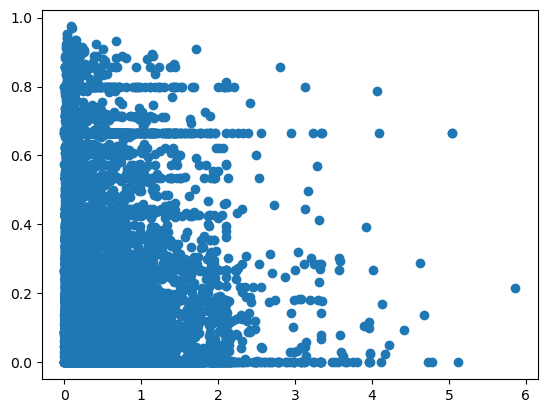

In [19]:
plt.scatter(df["distance_to_pointset"], df["clustering"])

In [ ]:
# bf.flow() was already called during Flow setup above

In [28]:
bf.best_fits['closeness'].observed_effect_strength

np.float64(-0.009806089618273383)

In [29]:
bf.best_fits['closeness'].observed_half_life

np.float64(0.043425761191166985)

In [ ]:
bf.best_fits['closeness'].fraction_not_converged  # property, not a method call

In [35]:
bf.fit_quality

,measure,best_fit_type,entropy_AIC_weights,observed_half_life,observed_effect_strength,included samples,affected samples,piecewise_linear_b,piecewise_linear_m,piecewise_linear_c,Piecewise Linear Fit_scaled_relative_likelihood_over_Constant Fit,Piecewise Linear Fit_AIC_weight,Exponential Saturation Fit_scaled_relative_likelihood_over_Constant Fit,Exponential Saturation Fit_AIC_weight,Michaelis-Menten Fit_scaled_relative_likelihood_over_Constant Fit,Michaelis-Menten Fit_AIC_weight,michaelis_menten_a,michaelis_menten_b,michaelis_menten_c,constant_c
0,closeness,Piecewise Linear Fit,1.098612,0.043426,-0.009806,0.518977,0.442834,0.086479,0.052589,0.228608,1.000074,0.333335,1.000068,0.333333,1.000067,0.333332,NaN,NaN,NaN,NaN
1,degree,Michaelis-Menten Fit,1.098612,0.427400,-0.147254,0.518977,1.000000,NaN,NaN,NaN,1.000202,0.333333,1.000204,0.333333,1.000206,0.333334,8.325853,0.49948,22.190569,NaN
2,clustering,Constant Fit,1.098612,0.000000,0.000000,0.518977,0.000000,NaN,NaN,NaN,0.999969,0.333334,0.999967,0.333333,0.999967,0.333333,NaN,NaN,NaN,0.167839
